<a href="https://colab.research.google.com/github/ecem-gunes/Machine_Learning_Projects/blob/main/C45_Random_Forest_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive + Veri Okuma + Label Encoding


In [ ]:
import numpy as np
import pandas as pd
import math
import random
from google.colab import drive

drive.mount("/content/drive")

# Dosya yolları
train_path = "/content/drive/MyDrive/Machine_learning_assignment1/X_train.xlsx"
test_path  = "/content/drive/MyDrive/Machine_learning_assignment1/X_test.xlsx"

train_df = pd.read_excel(train_path)
test_df  = pd.read_excel(test_path)

# Manuel class mapping
label_mapping = {"low": 0, "medium": 1, "high": 2, "very high": 3}
inv_label_mapping = {v: k for k, v in label_mapping.items()}

train_df["target"] = train_df["Sınıf"].map(label_mapping)
test_df["target"]  = test_df["Sınıf"].map(label_mapping)

feature_names = ["Neighborhood", "Price (TRY)", "Age (Years)", "Net Square Meters (m2)"]

X_train = train_df[feature_names].values
y_train = train_df["target"].values.astype(int)

X_test = test_df[feature_names].values
y_test = test_df["target"].values.astype(int)

print("Eğitim seti:", X_train.shape, " Test seti:", X_test.shape)
print(train_df.head())
print(train_df.columns)

Mounted at /content/drive
Eğitim seti: (501, 4)  Test seti: (126, 4)
   Neighborhood  Price (TRY)  Age (Years)  Net Square Meters (m2)      Sınıf  \
0  Ataşehir Mh.      8950000           13                     140       high   
1  Ataşehir Mh.     17750000           18                     150  very high   
2  Ataşehir Mh.     17250000           13                     150  very high   
3  Ataşehir Mh.     16500000           13                     140       high   
4  Ataşehir Mh.     15380000           18                     160  very high   

   target  
0       2  
1       3  
2       3  
3       2  
4       3  
Index(['Neighborhood', 'Price (TRY)', 'Age (Years)', 'Net Square Meters (m2)',
       'Sınıf', 'target'],
      dtype='object')


PART A - DECISION TREE, C4.5 (GAIN RATIO)

In [ ]:
class Node:
  # Decision tree node yapısı
    def __init__(self, feature=None, threshold=None, results=None, children=None):
        self.feature = feature
        self.threshold = threshold
        self.results = results
        self.children = children or {}

def entropy(y):
  # Shannon entropy hesabı
    if len(y) == 0:
        return 0.0
    counts = np.bincount(y)
    probs = counts[counts > 0] / len(y)
    return -np.sum(probs * np.log2(probs))

def gain_ratio(parent_y, subsets):
  # C4.5 gain ratio = information gain / split info
    parent_ent = entropy(parent_y)
    n = len(parent_y)

    weighted_ent = 0.0
    split_info = 0.0

    for sub in subsets:
        if len(sub) == 0:
            continue
        p = len(sub) / n
        weighted_ent += p * entropy(sub)
        split_info -= p * math.log2(p)

    info_gain = parent_ent - weighted_ent
    if split_info == 0:
        return 0.0
    return info_gain / split_info

def _candidate_thresholds_numeric(col, y):
  # Numeric feature için class değiştiği noktalardan threshold üretiyorum
    order = np.argsort(col)
    col_s = col[order]
    y_s = y[order]

    thrs = []
    for i in range(1, len(col_s)):
        if y_s[i] != y_s[i - 1]:
            thrs.append((col_s[i] + col_s[i - 1]) / 2.0)

    if len(thrs) == 0:
        return np.array([])
    return np.unique(np.array(thrs, dtype=float))

def find_best_split(X, y, available_features):
  # Tüm feature'lar için en iyi gain ratio'yu arıyorum
    best_gr = -1.0
    best = None

    for fi in available_features:
        col = X[:, fi]

        # Categorical feature (Neighborhood)
        if isinstance(col[0], str):
            values = np.unique(col)
            subsets = [y[col == v] for v in values]
            gr = gain_ratio(y, subsets)
            if gr > best_gr:
                best_gr = gr
                best = {"feature": fi, "type": "cat", "values": values}

        else:
          # Numeric feature
            thrs = _candidate_thresholds_numeric(col.astype(float), y)
            for thr in thrs:
                left = y[col.astype(float) <= thr]
                right = y[col.astype(float) > thr]
                gr = gain_ratio(y, [left, right])
                if gr > best_gr:
                    best_gr = gr
                    best = {"feature": fi, "type": "num", "threshold": float(thr)}

    return best, best_gr

def build_tree(X, y, available_features=None, depth=0, max_depth=None, min_samples_split=2):
    # Karar ağacını recursive şekilde kuruyorum
    if len(np.unique(y)) == 1:
        return Node(results=int(y[0]))

    if len(y) < min_samples_split:
        return Node(results=int(np.argmax(np.bincount(y))))

    if max_depth is not None and depth >= max_depth:
        return Node(results=int(np.argmax(np.bincount(y))))

    if available_features is None:
        available_features = list(range(X.shape[1]))

    if len(available_features) == 0:
        return Node(results=int(np.argmax(np.bincount(y))))

    split, gr = find_best_split(X, y, available_features)

    if split is None or gr <= 0:
        return Node(results=int(np.argmax(np.bincount(y))))

    fi = split["feature"]
    children = {}

    if split["type"] == "cat":
        next_features = [f for f in available_features if f != fi]
        for v in split["values"]:
            mask = X[:, fi] == v
            if mask.sum() == 0:
                continue
            children[v] = build_tree(
                X[mask], y[mask],
                available_features=next_features,
                depth=depth + 1,
                max_depth=max_depth,
                min_samples_split=min_samples_split
            )
        return Node(feature=fi, threshold=None, children=children)

    else:
        thr = split["threshold"]
        col = X[:, fi].astype(float)
        left_mask = col <= thr
        right_mask = col > thr

        if left_mask.sum() > 0:
            children["left"] = build_tree(
                X[left_mask], y[left_mask],
                available_features=available_features,
                depth=depth + 1,
                max_depth=max_depth,
                min_samples_split=min_samples_split
            )
        if right_mask.sum() > 0:
            children["right"] = build_tree(
                X[right_mask], y[right_mask],
                available_features=available_features,
                depth=depth + 1,
                max_depth=max_depth,
                min_samples_split=min_samples_split
            )
        return Node(feature=fi, threshold=thr, children=children)

Tahmin ve Metrikler

In [ ]:
def predict_one(node, sample):
    while node.results is None:
        val = sample[node.feature]
        if node.threshold is not None:
            # sayısal
            direction = "left" if float(val) <= node.threshold else "right"
            if direction not in node.children:
                return 0
            node = node.children[direction]
        else:
            # kategorik
            if val not in node.children:
                return 0
            node = node.children[val]
    return int(node.results)

def predict(node, X):
    return np.array([predict_one(node, x) for x in X], dtype=int)

def confusion_matrix_manual(y_true, y_pred, n_classes=4):
  # Confusion matrix'i numpy ile elle hesaplıyorum
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

def metrics_manual(y_true, y_pred, n_classes=4):
    cm = confusion_matrix_manual(y_true, y_pred, n_classes=n_classes)
    total = int(cm.sum())
    total_TP = int(np.trace(cm))
    accuracy = total_TP / total if total else 0.0

    precisions, recalls, f1s = [], [], []
    total_TN, total_FP = 0, 0

    for c in range(n_classes):
        TP = int(cm[c, c])
        FP = int(cm[:, c].sum() - TP)
        FN = int(cm[c, :].sum() - TP)
        TN = int(total - (TP + FP + FN))

        total_TN += TN
        total_FP += FP

        prec = TP / (TP + FP) if (TP + FP) else 0.0
        rec = TP / (TP + FN) if (TP + FN) else 0.0
        f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) else 0.0

        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f1)

    precision_macro = float(np.mean(precisions))
    recall_macro = float(np.mean(recalls))
    f1_macro = float(np.mean(f1s))
    TN_rate = (total_TN / (total_TN + total_FP)) if (total_TN + total_FP) else 0.0

    return {
        "accuracy": accuracy,
        "recall_macro": recall_macro,
        "TN_rate": TN_rate,
        "precision_macro": precision_macro,
        "f1_macro": f1_macro,
        "total_TP": total_TP,
        "total_TN": int(total_TN),
        "cm": cm,
    }

def print_performance(y_true, y_pred, title):
  # Assignment formatındaki metrik çıktısı
    m = metrics_manual(y_true, y_pred, n_classes=4)
    print(f"\n--- {title} ---")
    print(f"Accuracy: {m['accuracy']:.3f}")
    print(f"TP Rate (Recall): {m['recall_macro']:.3f}")
    print(f"TN Rate: {m['TN_rate']:.3f}")
    print(f"Precision: {m['precision_macro']:.3f}")
    print(f"F-Score: {m['f1_macro']:.3f}")
    print(f"Total Number of TP: {m['total_TP']}")
    print(f"Total Number of TN: {m['total_TN']}")
    return m

Karar Ağacını Eğitme ve sonuçlar

In [ ]:
# Fully grown decision tree (C4.5)
root = build_tree(X_train, y_train, max_depth=None, min_samples_split=2)

y_train_pred = predict(root, X_train)
y_test_pred = predict(root, X_test)

train_metrics = print_performance(y_train, y_train_pred, "Train Results (Decision Tree - C4.5 Gain Ratio)")
test_metrics  = print_performance(y_test, y_test_pred, "Test Results (Decision Tree - C4.5 Gain Ratio)")


--- Train Results (Decision Tree - C4.5 Gain Ratio) ---
Accuracy: 1.000
TP Rate (Recall): 1.000
TN Rate: 1.000
Precision: 1.000
F-Score: 1.000
Total Number of TP: 501
Total Number of TN: 1503

--- Test Results (Decision Tree - C4.5 Gain Ratio) ---
Accuracy: 0.659
TP Rate (Recall): 0.675
TN Rate: 0.886
Precision: 0.663
F-Score: 0.660
Total Number of TP: 83
Total Number of TN: 335


PART B - RANDOM FOREST + test skorları

In [ ]:
def build_rf(X, y, n_trees=20, subspace_size=3, seed=42):
  # Random forest içinde her ağaç için random subspace seçiyorum
    random.seed(seed)
    forest = []
    n_features = X.shape[1]

    for _ in range(n_trees):
        feat_idxs = random.sample(range(n_features), subspace_size)
        X_sub = X[:, feat_idxs]
        tree = build_tree(X_sub, y, max_depth=None, min_samples_split=2)
        forest.append((tree, feat_idxs))

    return forest

def rf_predict_one(forest, sample):
  # Her ağaçtan oy alıp majority vote yapıyorum
    votes = []
    for tree, idxs in forest:
        votes.append(predict_one(tree, sample[idxs]))
    return max(set(votes), key=votes.count)

def rf_predict(forest, X):
    return np.array([rf_predict_one(forest, x) for x in X], dtype=int)

forest = build_rf(X_train, y_train, n_trees=20, subspace_size=3, seed=42)
y_rf_test_pred = rf_predict(forest, X_test)

rf_test_metrics = print_performance(y_test, y_rf_test_pred, "Test Results (Random Forest)")


--- Test Results (Random Forest) ---
Accuracy: 0.714
TP Rate (Recall): 0.700
TN Rate: 0.905
Precision: 0.701
F-Score: 0.694
Total Number of TP: 90
Total Number of TN: 342


Ağaç yapısı Rapor için

In [ ]:
def print_tree(node, depth=0):
  # Tree yapısını indentation ile text olarak gösteriyorum
    indent = "  " * depth
    if node.results is not None:
        print(f"{indent}-> Sınıf: {inv_label_mapping.get(int(node.results), node.results)}")
        return

    name = feature_names[int(node.feature)]
    if node.threshold is not None:
        print(f"{indent}|-- {name} <= {node.threshold:.2f}")
        if "left" in node.children:
            print(f"{indent}  [True/left]:")
            print_tree(node.children["left"], depth + 2)
        if "right" in node.children:
            print(f"{indent}  [False/right]:")
            print_tree(node.children["right"], depth + 2)
    else:
        print(f"{indent}|-- {name}")
        for k, ch in sorted(node.children.items(), key=lambda kv: str(kv[0])):
            print(f"{indent}  [{k}]:")
            print_tree(ch, depth + 2)

print_tree(root)

|-- Price (TRY) <= 8924999.50
  [True/left]:
    |-- Price (TRY) <= 5550000.00
      [True/left]:
        |-- Age (Years) <= 5.00
          [True/left]:
            |-- Net Square Meters (m2) <= 70.00
              [True/left]:
                -> Sınıf: low
              [False/right]:
                |-- Net Square Meters (m2) <= 127.50
                  [True/left]:
                    -> Sınıf: medium
                  [False/right]:
                    -> Sınıf: high
          [False/right]:
            |-- Net Square Meters (m2) <= 150.00
              [True/left]:
                |-- Age (Years) <= 18.00
                  [True/left]:
                    |-- Neighborhood
                      [ALSANCAK]:
                        -> Sınıf: medium
                      [Alaybey]:
                        -> Sınıf: low
                      [Aydoğdu ]:
                        -> Sınıf: low
                      [Balatçık Mh.]:
                        -> Sınıf: medium
                 

Decision Tree Diagram

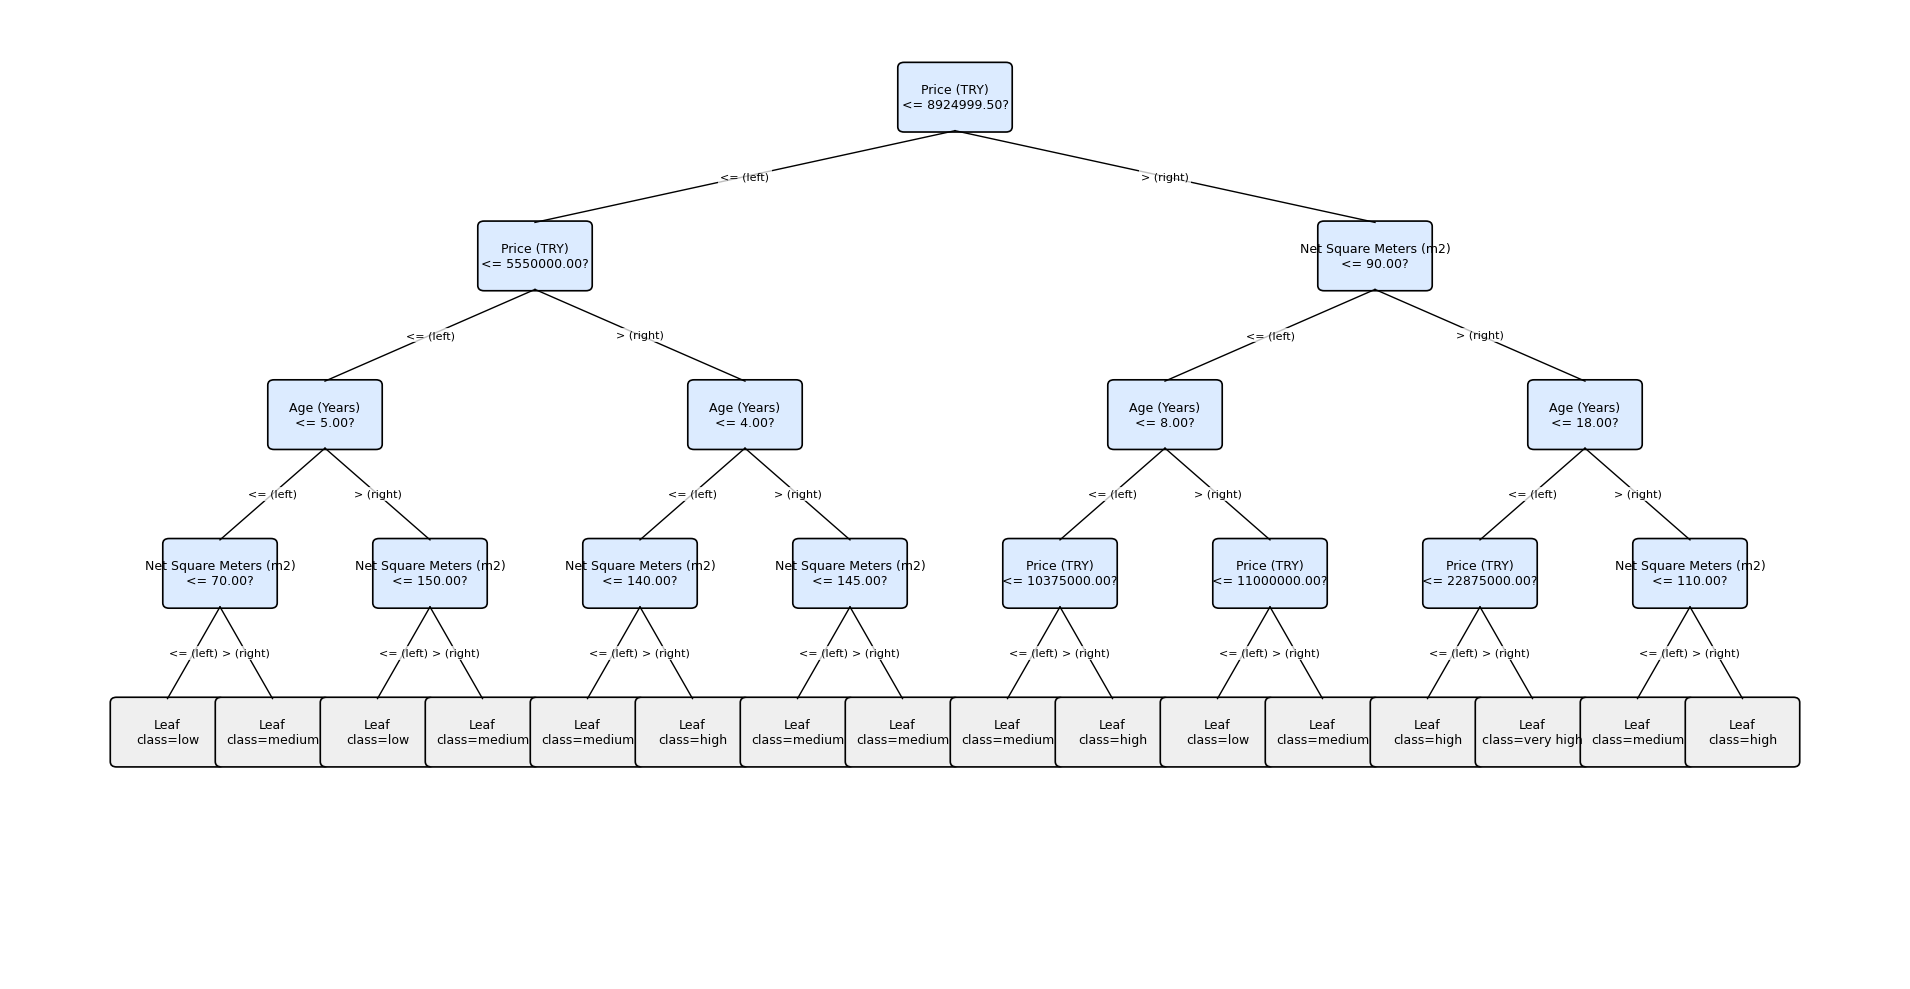

Saved diagram: c45_tree_small.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def _is_leaf(n):
    return n.results is not None

def _leaf_count(n):
    if _is_leaf(n) or not n.children:
        return 1
    return sum(_leaf_count(ch) for ch in n.children.values())

def _tree_depth(n):
    if _is_leaf(n) or not n.children:
        return 1
    return 1 + max(_tree_depth(ch) for ch in n.children.values())

def _children_items(n):
    if n.threshold is not None:
        items = []
        if "left" in n.children:  items.append(("left",  n.children["left"]))
        if "right" in n.children: items.append(("right", n.children["right"]))
        return items
    return sorted(n.children.items(), key=lambda kv: str(kv[0]))

def _node_label(n):
    if _is_leaf(n):
        return f"Leaf\nclass={inv_label_mapping.get(int(n.results), n.results)}"
    fname = feature_names[int(n.feature)]
    if n.threshold is not None:
        return f"{fname}\n<= {float(n.threshold):.2f}?"
    return f"{fname}"

def _edge_label(parent, key):
    if parent.threshold is not None:
        return "<= (left)" if key == "left" else "> (right)"
    return str(key)

def draw_tree(root, save_path="c45_tree_small.png", dpi=250):
    leaves = _leaf_count(root)
    depth = _tree_depth(root)

    fig_w = max(12, leaves * 1.2)
    fig_h = max(6, depth * 2.0)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    y_step = 1.8
    pos = {}

    def layout(n, x0, x1, y):
        if _is_leaf(n) or not n.children:
            x = (x0 + x1) / 2
            pos[id(n)] = (x, y)
            return x

        items = _children_items(n)
        total = sum(_leaf_count(ch) for _, ch in items)
        cur = x0
        centers = []

        for key, ch in items:
            w = (x1 - x0) * (_leaf_count(ch) / total)
            cx = layout(ch, cur, cur + w, y - y_step)
            centers.append(cx)
            cur += w

        x = float(np.mean(centers))
        pos[id(n)] = (x, y)
        return x

    layout(root, 0.0, float(leaves), 0.0)

    def draw(n):
        x, y = pos[id(n)]

        box_w, box_h = 1.05, 0.75
        rect = mpatches.FancyBboxPatch(
            (x - box_w/2, y - box_h/2),
            box_w, box_h,
            boxstyle="round,pad=0.02,rounding_size=0.06",
            linewidth=1.2,
            edgecolor="black",
            facecolor="#EFEFEF" if _is_leaf(n) else "#DCEBFF"
        )
        ax.add_patch(rect)
        ax.text(x, y, _node_label(n), ha="center", va="center", fontsize=9)

        if _is_leaf(n) or not n.children:
            return

        for key, ch in _children_items(n):
            cx, cy = pos[id(ch)]
            ax.plot([x, cx], [y - 0.38, cy + 0.38], color="black", linewidth=1.0)

            midx, midy = (x + cx) / 2, (y + cy) / 2
            ax.text(
                midx, midy, _edge_label(n, key),
                fontsize=8, ha="center", va="center",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5)
            )
            draw(ch)

    draw(root)

    ax.set_xlim(-1.0, float(leaves) + 1.0)
    ax.set_ylim(-(depth * y_step) - 1.0, 1.0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

    print("Saved diagram:", save_path)

# Sadece görsel için daha kısa bir ağaç üretiyorum
root_diag = build_tree(
    X_train,
    y_train,
    max_depth=4,
    min_samples_split=5
)

draw_tree(root_diag, save_path="c45_tree_small.png", dpi=250)